# Numpy Vectors Exercise
Authors: Yiran and Laura

In [ ]:
# imports necessary for this notebook
import numpy as np
from matplotlib import pyplot as plt
from ineqpy.inequality import gini

results = {}

## Exercise 1

In [25]:
# Exercise 1
income = np.loadtxt('https://raw.githubusercontent.com/nickeubank/practicaldatascience/master/Example_Data/us_household_incomes.txt')

## Exercise 2

(array([8.77542e+05, 4.35030e+04, 1.01710e+04, 1.92100e+03, 3.98000e+02,
        1.17000e+02, 2.90000e+01, 8.00000e+00, 4.00000e+00, 2.00000e+00]),
 array([ -16942. ,  225842.5,  468627. ,  711411.5,  954196. , 1196980.5,
        1439765. , 1682549.5, 1925334. , 2168118.5, 2410903. ]),
 <BarContainer object of 10 artists>)

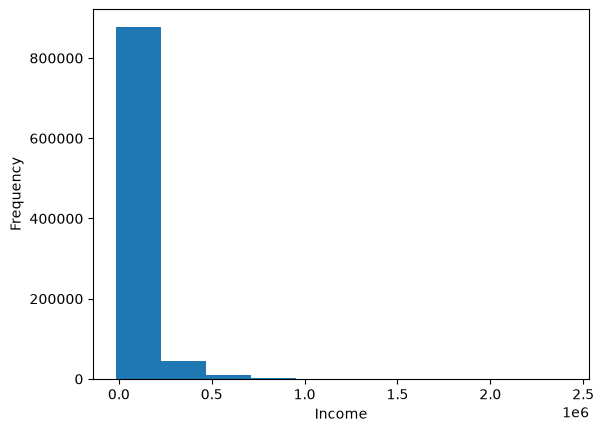

In [26]:
# Exercise 2
plt.xlabel('Income')
plt.ylabel('Frequency')
plt.hist(income)

It doesn't look normal - heavily right-skewed that even seems unimodal. This could be because of the scale of x-axis is set at unit of 1e6 and split by 0.5, while most people's income fall into the first histo-box. 

(array([262190., 338722., 173615.,  76580.,  33854.,  16134.,   8329.,
          5401.,   4556.,   4038.]),
 array([-16942.,  34752.,  86446., 138140., 189834., 241528., 293222.,
        344916., 396610., 448304., 499998.]),
 <BarContainer object of 10 artists>)

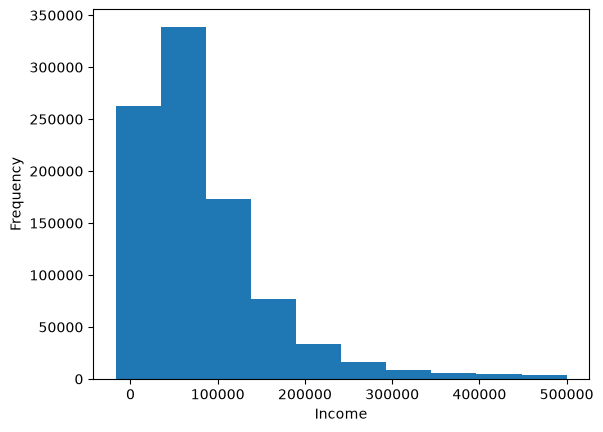

In [27]:
filtered_income = income[income < 500000]

plt.xlabel('Income')
plt.ylabel('Frequency')
plt.hist(filtered_income)

It's still right-skewed. This implies that the skewness is evident at all income levels.

In [28]:
# Exercise 4
filter_20k = income[income < 20000]
ex4_share_below_poverty = len(filter_20k) / len(income)
print(ex4_share_below_poverty)

ex4_gini = gini(income)
print(ex4_gini)

0.14711442173300704
0.4810925546879193


U.S. ranks 46th out of 162 countries on the World Bank GINI index ranking from high to low GINI values. The U.S. has the worst GINI index among developed countries.

It is sad, but this is what I expected.

## Exercise 6

In [31]:
# Exercise 6
# Policy A: $5,000 check to households with income below $40,000


policy_a_benefits = np.where(income < 40000, income + 5000, income)
print(results)
results["ex6_gini_policy_a"] = gini(policy_a_benefits)
print(results["ex6_gini_policy_a"])

{'ex6_gini_policy_a': np.float64(0.755547763489701), 'ex6_gini_policy_b': np.float64(0.7634074975052809)}
0.4602468507489467


In [32]:
# Policy B: $7,000 check to households with income below $30,000
policy_b_benefits = np.where(income < 30000, income + 7000, income)
results["ex6_gini_policy_b"] = gini(policy_b_benefits)
print(results["ex6_gini_policy_b"])

0.4582821778789717


In [ ]:
# Better policy
results["ex6_gini_which_reduced_more"] = "Policy A" if results["ex6_gini_policy_a"] < results["ex6_gini_policy_b"] else "Policy B"
#results["ex6_gini_which_reduced_more"]

'Policy B'

## Exercise 7
Policy c:
income tax of 5 % on households with income > $250,000

In [35]:
# Exercise 7
# 5 % reduction in income for households with income above $250,000
policy_c_benefits = np.where(income > 250000, income * 0.95, income)
results["ex7_gini_policy_c"] = gini(policy_c_benefits)
print(results["ex7_gini_policy_c"])

0.47561738439007106


## Exercise 8 - 10
Policy d: 5% tax to people with income > $250,000 and evenly distributed that tax revenue to households earning <$30,000 

In [37]:
# Exercise 8
# calculate the total tax revenue generated by a 5% tax on households with income below $30,000
filter_250k = income[income > 250000]
tax_revenue = np.sum(filter_250k * 0.05)

results["ex8_revenue_raised"] = tax_revenue
print(results["ex8_revenue_raised"])

929623340.8500001


In [38]:
# Exercise 9
# calculate the  number of households earning < $30,000, divide the revenue by the number of households earning less than 30,000 dollars
filter_30k = income[income < 30000]
num_under30k = len(filter_30k)
revenue_per_household = tax_revenue / num_under30k
results["ex9_revenue_per_household"] = revenue_per_household
print(results["ex9_revenue_per_household"])

4208.230382379837


In [ ]:
# Exercise 10
# Allocate the revenue_per_household to households with income below $30,000 and calculate the new Gini coefficient
# Make a copy of the original income array to avoid modifying it directly
policy_d_array = np.copy(income)
# Tax and redistribute
policy_d_array[policy_d_array >= 250000] *= 0.95
policy_d_array[policy_d_array < 30000] += revenue_per_household
# Calculate the Gini coefficient for the new income distribution
results["ex10_gini_policy_d"] = gini(policy_d_array)
print(results["ex10_gini_policy_d"])

0.4616560278577218
